In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
print("Environment ready for Nigeria EDA!")

Environment ready for Nigeria EDA!


In [2]:
# Load and tag
df = pd.read_csv("../data/nigeria.csv")
df['Country'] = 'Nigeria'

# Convert to datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

print(f"Nigeria dataset loaded: {df.shape}")
df.head()

Nigeria dataset loaded: (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


In [5]:
# Replace NASA -999 sentinel values with NaN [cite: 535]
df.replace(-999, np.nan, inplace=True)
print("Replaced all -999 with NaN")

# Check and drop duplicates [cite: 537]
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

Replaced all -999 with NaN
Duplicate rows found: 0


In [4]:
df.describe() # [cite: 538]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


Nigeria typically shows a strong north-south precipitation gradient.

High maximum temperatures (T2M_MAX) are expected, especially in northern regions.
* Wind speed variables (WS2M_MAX) may show seasonal peaks related to the Harmattan.

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("=== Missing Value Report ===")
print(missing[missing > 0])
# Note any column with >5% nulls [cite: 540]

=== Missing Value Report ===
Series([], dtype: int64)


In [7]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
for col in cols_to_check:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    outliers = (z_scores > 3).sum()
    print(f"{col}: {outliers} outliers (|Z| > 3)")

T2M: 10 outliers (|Z| > 3)
T2M_MAX: 1 outliers (|Z| > 3)
T2M_MIN: 68 outliers (|Z| > 3)
PRECTOTCORR: 75 outliers (|Z| > 3)
RH2M: 128 outliers (|Z| > 3)
WS2M: 5 outliers (|Z| > 3)
WS2M_MAX: 10 outliers (|Z| > 3)


In [8]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
df[weather_cols] = df[weather_cols].ffill()
df.to_csv("../data/nigeria_clean.csv", index=False)
print("Exported to data/nigeria_clean.csv")

Exported to data/nigeria_clean.csv


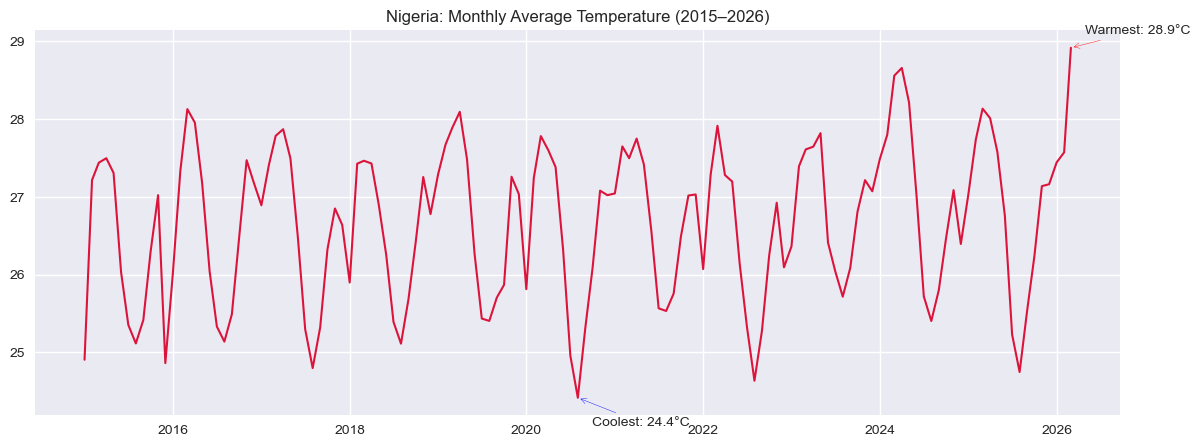

In [9]:
# Prepare data
monthly_temp = df.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['YEAR', 'Month']].assign(DAY=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_temp['Date'], monthly_temp['T2M'], color='crimson', linewidth=1.5)

# Annotate Warmest/Coolest
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

ax.annotate(f"Warmest: {warmest['T2M']:.1f}°C", xy=(warmest['Date'], warmest['T2M']),
            xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='red'))
ax.annotate(f"Coolest: {coolest['T2M']:.1f}°C", xy=(coolest['Date'], coolest['T2M']),
            xytext=(10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='blue'))

ax.set_title('Nigeria: Monthly Average Temperature (2015–2026)')
plt.savefig('../notebooks/nigeria_temp_timeseries.png')
plt.show()

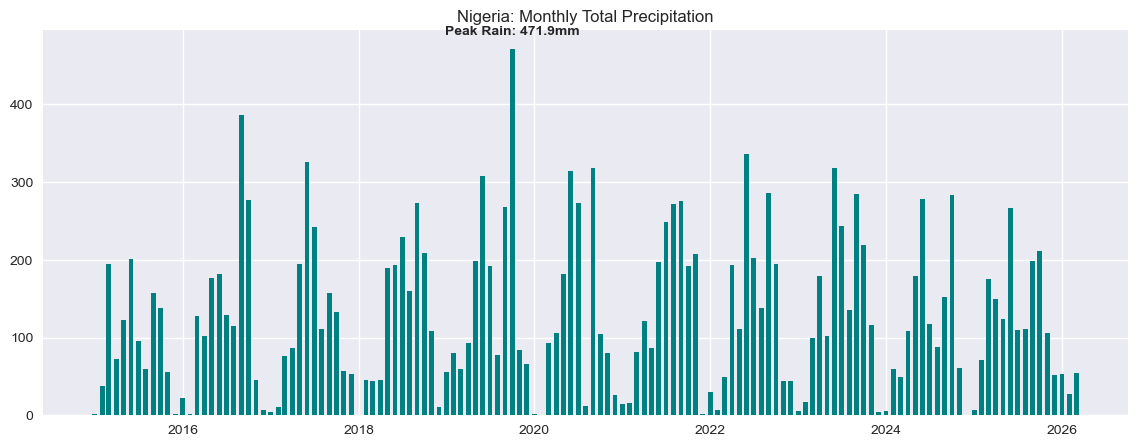

In [10]:
monthly_precip = df.groupby(['YEAR', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(monthly_precip[['YEAR', 'Month']].assign(DAY=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_precip['Date'], monthly_precip['PRECTOTCORR'], color='teal', width=20)

# Annotate Peak
peak = monthly_precip.loc[monthly_precip['PRECTOTCORR'].idxmax()]
ax.annotate(f"Peak Rain: {peak['PRECTOTCORR']:.1f}mm", xy=(peak['Date'], peak['PRECTOTCORR']),
            xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

ax.set_title('Nigeria: Monthly Total Precipitation')
plt.savefig('../notebooks/nigeria_precip_timeseries.png')
plt.show()

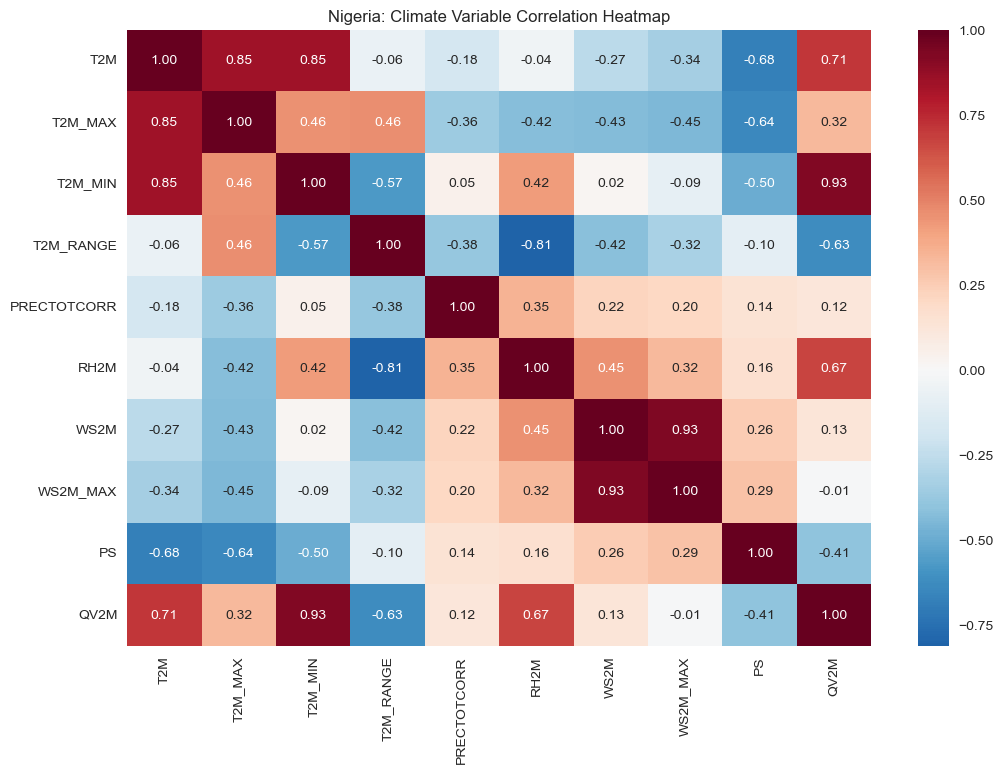

In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Nigeria: Climate Variable Correlation Heatmap')
plt.savefig('../notebooks/nigeria_correlation_heatmap.png')
plt.show()

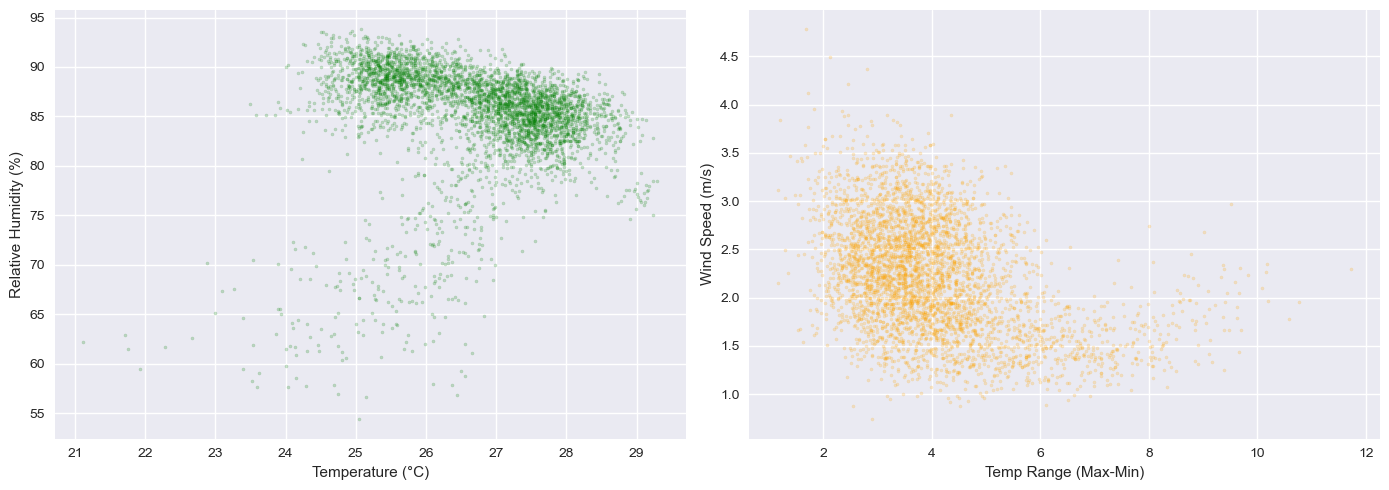

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.2, s=5, color='green')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')

# T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.2, s=5, color='orange')
axes[1].set_xlabel('Temp Range (Max-Min)')
axes[1].set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.savefig('../notebooks/nigeria_scatter_plots.png')
plt.show()

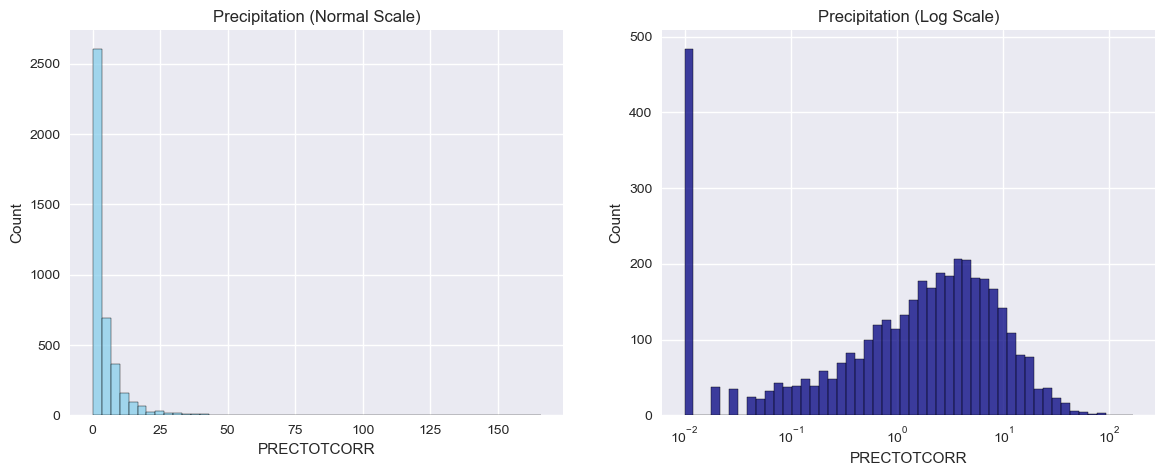

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal Scale
sns.histplot(df['PRECTOTCORR'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Precipitation (Normal Scale)')

# Log Scale (Adding small constant to avoid log(0))
sns.histplot(df['PRECTOTCORR'] + 0.01, bins=50, ax=axes[1], color='navy', log_scale=True)
axes[1].set_title('Precipitation (Log Scale)')

plt.savefig('../notebooks/nigeria_precip_distribution.png')
plt.show()

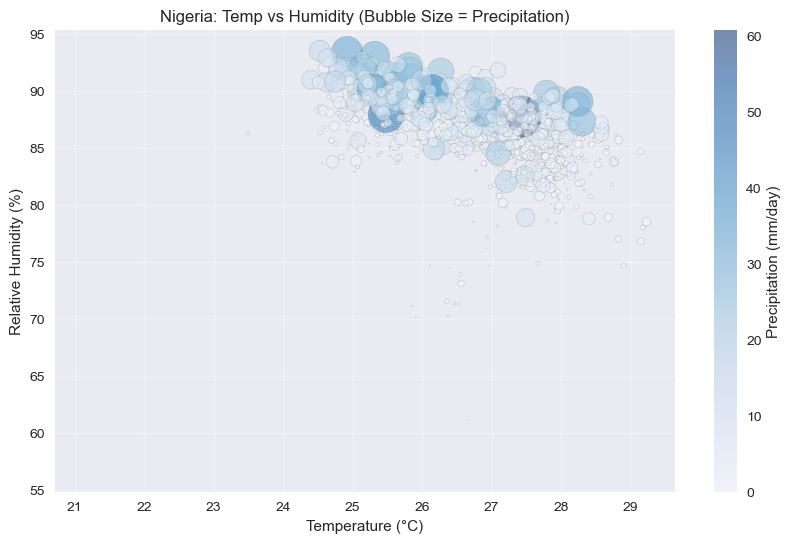

In [14]:
# Sample data to keep the plot readable
sample = df.sample(n=1000, random_state=42)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(sample['T2M'], sample['RH2M'], 
                      s=sample['PRECTOTCORR'] * 15, # Size based on rain
                      c=sample['PRECTOTCORR'],      
                      cmap='Blues', alpha=0.5, edgecolors='grey')

plt.colorbar(scatter, label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Nigeria: Temp vs Humidity (Bubble Size = Precipitation)')
plt.grid(True, alpha=0.3)
plt.savefig('../notebooks/nigeria_bubble_chart.png')
plt.show()